# Notebook 06 (No Augmentation) — 1D-CNN Classification with 5-Fold Stratified Cross Validation

This notebook trains and evaluates a **1D Convolutional Neural Network (1D-CNN)** for binary
classification of NIR corn spectra using **5-Fold Stratified Cross Validation**, **without any data augmentation**.

This is a variant of `revised/06_1d_cnn_revised.ipynb`. The only difference is that
the interpolation augmentation step is removed — the CNN is trained directly on the
raw ~56 training samples per fold after carving out a real validation set.

## Section 1 — Imports and Setup

In [1]:
import sys
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

sys.path.append('../..')

from src.cnn_trainer import (
    build_1d_cnn,
    reshape_for_cnn,
    plot_training_history,
    plot_cnn_confusion_matrix,
)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

print('All libraries imported successfully.')
print(f'TensorFlow version : {tf.__version__}')
print(f'NumPy version      : {np.__version__}')
print('NOTE: No augmentation — CNN trained on raw training samples per fold.')

All libraries imported successfully.
TensorFlow version : 2.21.0
NumPy version      : 2.4.4
NOTE: No augmentation — CNN trained on raw training samples per fold.


## Section 2 — Load Full Dataset

In [2]:
X = np.load('../../data/processed/X_preprocessed.npy')
y = np.load('../../data/processed/y_labels.npy')

print(f'X shape : {X.shape}  (samples x wavelengths)')
print(f'y shape : {y.shape}')
print()
print('Class distribution:')
unique, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(unique, counts):
    label = 'High-Protein (1)' if cls == 1 else 'Low-Protein  (0)'
    print(f'  Class {int(cls)} — {label}: {cnt} samples')
print(f'\nTotal samples: {len(y)}')

X shape : (539, 700)  (samples x wavelengths)
y shape : (539,)

Class distribution:
  Class 0 — Low-Protein  (0): 269 samples
  Class 1 — High-Protein (1): 270 samples

Total samples: 539


## Section 3 — Define 5-Fold Stratified Cross Validation

In [3]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('5-Fold Stratified Cross Validation configured.')
print(f'  n_splits     : {skf.n_splits}')
print(f'  shuffle      : {skf.shuffle}')
print(f'  random_state : {skf.random_state}')
print(f'\nEach fold: ~{len(y) // skf.n_splits} test samples, '
      f'~{len(y) - len(y) // skf.n_splits} training samples')

5-Fold Stratified Cross Validation configured.
  n_splits     : 5
  shuffle      : True
  random_state : 42

Each fold: ~107 test samples, ~432 training samples


## Section 4 — 1D-CNN 5-Fold Cross Validation (No Augmentation)

Each fold follows this pipeline:

1. **Split** — 64 training samples and 16 test samples (stratified).
2. **Real validation set** — ~8 real spectra are held out from the 64-sample training fold using `StratifiedShuffleSplit`. These are passed as `validation_data` to `model.fit()` so that `EarlyStopping` monitors genuine, unseen spectra.
3. **No augmentation** — the remaining ~56 training samples are used directly.
4. **Scaling** — `StandardScaler` is fitted exclusively on the ~56 raw training samples and used to transform the validation and test sets.
5. **Reshape** — adds the channel dimension required by Conv1D: `(n, 700)` → `(n, 700, 1)`.
6. **Training** — up to 100 epochs, batch size 32. `EarlyStopping` (patience=20) monitors `val_loss`.
7. **Best model tracking** — fold with highest F1 on test fold is retained.


  Fold 1 / 5
  Train fold : 431 samples
  Test fold  : 108 samples
  Training (no aug) : 377 samples
  Real validation   : 54 samples (used by EarlyStopping)


Model: "1d_cnn_protein_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_20 (Conv1D)              │ (None, 700, 32)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 700, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_20 (MaxPooling1D) │ (None, 350, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 350, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 350, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_21 (MaxPooling1D) │ (None, 175, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 11200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │       358,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 373,633 (1.43 MB)

 Trainable params: 373,441 (1.42 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.6313 - loss: 0.7396 - val_accuracy: 0.5556 - val_loss: 0.6945
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6499 - loss: 0.7482 - val_accuracy: 0.6111 - val_loss: 0.6878
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7082 - loss: 0.6162 - val_accuracy: 0.6667 - val_loss: 0.6853
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7401 - loss: 0.5578 - val_accuracy: 0.6852 - val_loss: 0.6825
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7268 - loss: 0.5499 - val_accuracy: 0.5741 - val_loss: 0.6839
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7454 - loss: 0.5363 - val_accuracy: 0.5556 - val_loss: 0.6805
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7454 - loss: 0.5201 - val_accuracy: 0.5556 - val_loss: 0.6802
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7480 - loss: 0.4984 - val_accuracy: 0.5000 - val_loss:

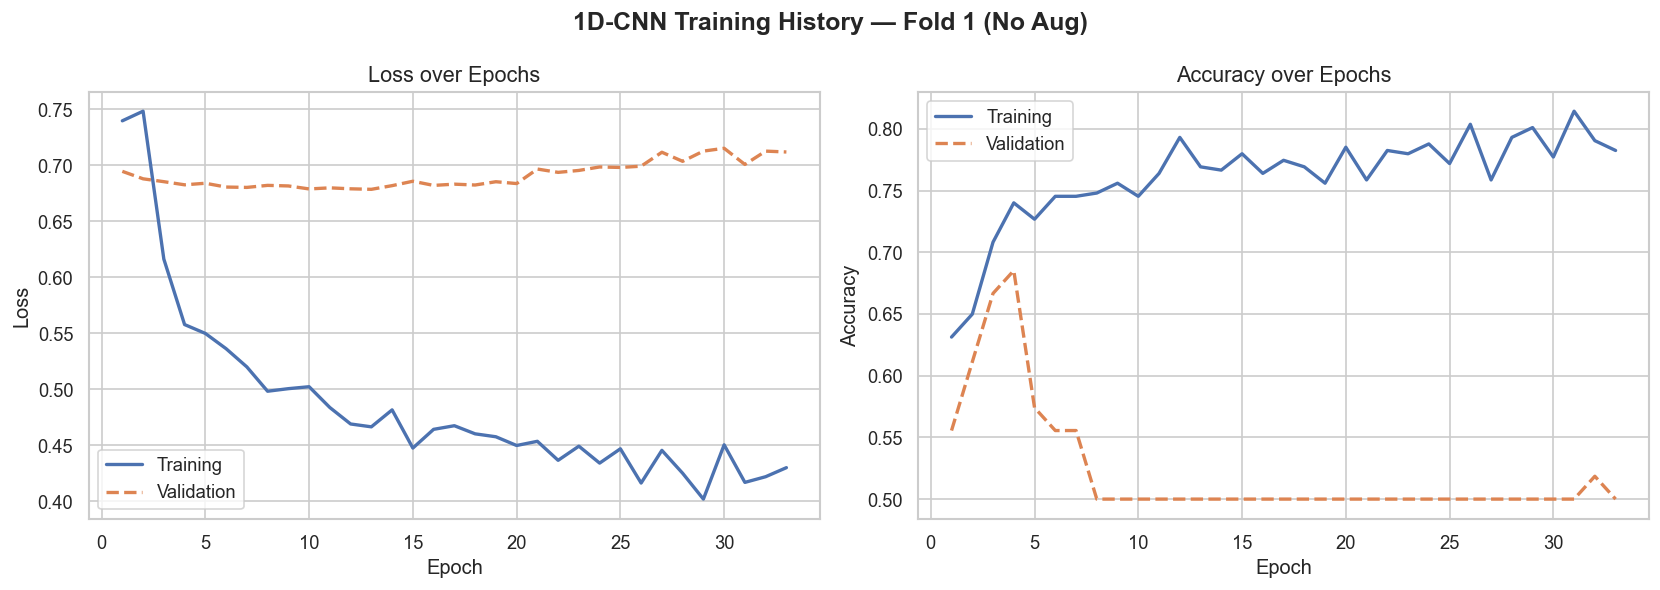

Fold 1: Accuracy=0.5185  Precision=0.5094  Recall=1.0000  F1=0.6750
  *** New best model (Fold 1, F1 = 0.6750) ***

  Fold 2 / 5
  Train fold : 431 samples
  Test fold  : 108 samples
  Training (no aug) : 377 samples
  Real validation   : 54 samples (used by EarlyStopping)


Model: "1d_cnn_protein_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_22 (Conv1D)              │ (None, 700, 32)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 700, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_22 (MaxPooling1D) │ (None, 350, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 350, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 350, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_23 (MaxPooling1D) │ (None, 175, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 11200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │       358,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 373,633 (1.43 MB)

 Trainable params: 373,441 (1.42 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.5703 - loss: 0.8187 - val_accuracy: 0.6111 - val_loss: 0.6870
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7056 - loss: 0.5922 - val_accuracy: 0.6481 - val_loss: 0.6807
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6897 - loss: 0.6527 - val_accuracy: 0.6296 - val_loss: 0.6784
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7162 - loss: 0.5719 - val_accuracy: 0.6111 - val_loss: 0.6795
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7029 - loss: 0.5456 - val_accuracy: 0.6296 - val_loss: 0.6795
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7162 - loss: 0.5423 - val_accuracy: 0.5926 - val_loss: 0.6797
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7268 - loss: 0.5183 - val_accuracy: 0.5370 - val_loss: 0.6786
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7294 - loss: 0.5214 - val_accuracy: 0.5370 - val_loss:

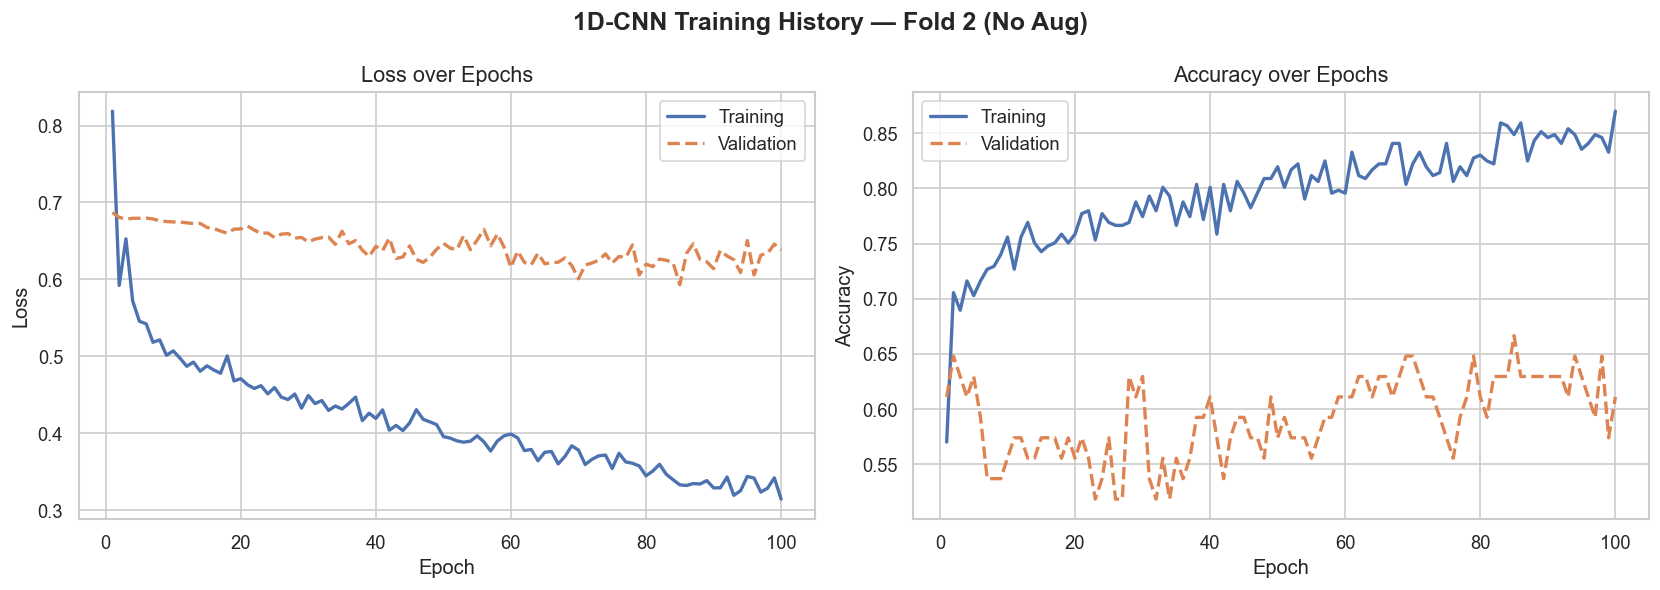

Fold 2: Accuracy=0.6574  Precision=0.6104  Recall=0.8704  F1=0.7176
  *** New best model (Fold 2, F1 = 0.7176) ***

  Fold 3 / 5
  Train fold : 431 samples
  Test fold  : 108 samples
  Training (no aug) : 377 samples
  Real validation   : 54 samples (used by EarlyStopping)


Model: "1d_cnn_protein_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_24 (Conv1D)              │ (None, 700, 32)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 700, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_24 (MaxPooling1D) │ (None, 350, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 350, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 350, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_25 (MaxPooling1D) │ (None, 175, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 11200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │       358,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 373,633 (1.43 MB)

 Trainable params: 373,441 (1.42 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.5968 - loss: 0.8718 - val_accuracy: 0.5741 - val_loss: 0.6826
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6446 - loss: 0.6801 - val_accuracy: 0.7037 - val_loss: 0.6840
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6897 - loss: 0.6036 - val_accuracy: 0.7222 - val_loss: 0.6807
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7029 - loss: 0.5958 - val_accuracy: 0.6111 - val_loss: 0.6830
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7135 - loss: 0.5547 - val_accuracy: 0.6667 - val_loss: 0.6794
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7241 - loss: 0.5409 - val_accuracy: 0.6111 - val_loss: 0.6782
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7003 - loss: 0.5464 - val_accuracy: 0.5741 - val_loss: 0.6793
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7401 - loss: 0.5013 - val_accuracy: 0.5926 - val_loss:

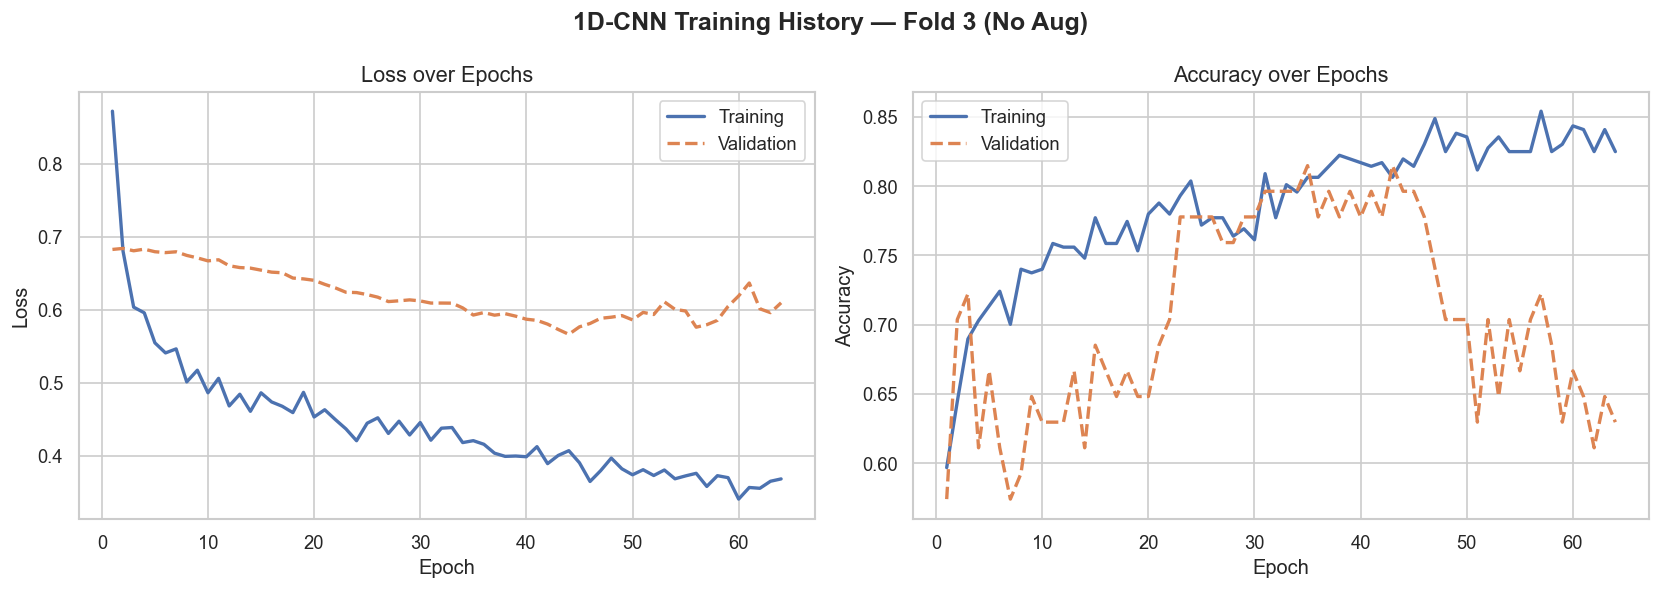

Fold 3: Accuracy=0.6667  Precision=0.8000  Recall=0.4444  F1=0.5714

  Fold 4 / 5
  Train fold : 431 samples
  Test fold  : 108 samples
  Training (no aug) : 377 samples
  Real validation   : 54 samples (used by EarlyStopping)


Model: "1d_cnn_protein_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_26 (Conv1D)              │ (None, 700, 32)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 700, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_26 (MaxPooling1D) │ (None, 350, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_27 (Conv1D)              │ (None, 350, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 350, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_27 (MaxPooling1D) │ (None, 175, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 11200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │       358,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 373,633 (1.43 MB)

 Trainable params: 373,441 (1.42 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.6048 - loss: 0.7501 - val_accuracy: 0.5926 - val_loss: 0.6848
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7082 - loss: 0.5660 - val_accuracy: 0.6481 - val_loss: 0.6894
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6870 - loss: 0.5640 - val_accuracy: 0.6667 - val_loss: 0.6802
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7268 - loss: 0.5666 - val_accuracy: 0.6667 - val_loss: 0.6790
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7401 - loss: 0.5201 - val_accuracy: 0.6481 - val_loss: 0.6792
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7454 - loss: 0.5195 - val_accuracy: 0.5926 - val_loss: 0.6827
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7507 - loss: 0.5097 - val_accuracy: 0.6296 - val_loss: 0.6827
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7268 - loss: 0.5102 - val_accuracy: 0.6852 - val_loss:

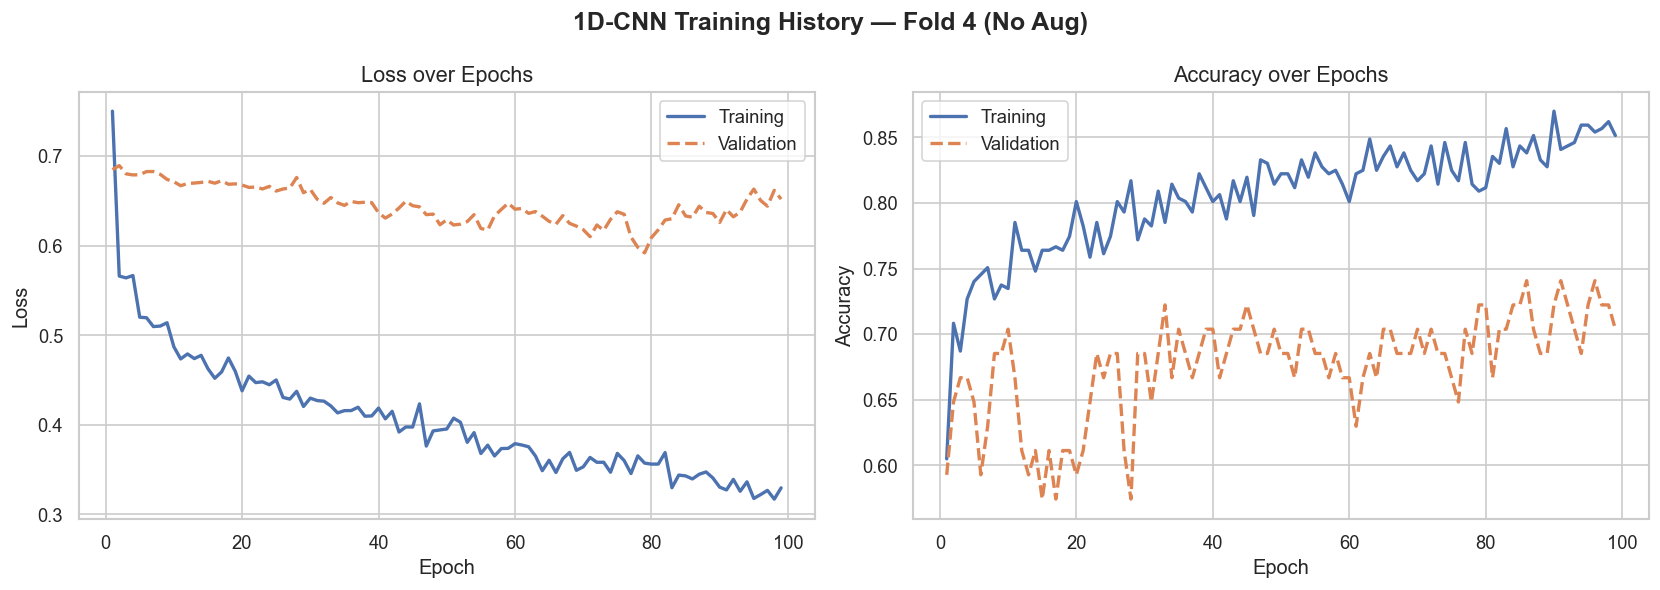

Fold 4: Accuracy=0.7130  Precision=0.7949  Recall=0.5741  F1=0.6667

  Fold 5 / 5
  Train fold : 432 samples
  Test fold  : 107 samples
  Training (no aug) : 378 samples
  Real validation   : 54 samples (used by EarlyStopping)


Model: "1d_cnn_protein_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_28 (Conv1D)              │ (None, 700, 32)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 700, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_28 (MaxPooling1D) │ (None, 350, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_29 (Conv1D)              │ (None, 350, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 350, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_29 (MaxPooling1D) │ (None, 175, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 11200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │       358,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 373,633 (1.43 MB)

 Trainable params: 373,441 (1.42 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.6111 - loss: 0.7527 - val_accuracy: 0.6667 - val_loss: 0.6861
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6878 - loss: 0.6171 - val_accuracy: 0.5556 - val_loss: 0.6842
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7354 - loss: 0.5720 - val_accuracy: 0.5556 - val_loss: 0.6834
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7011 - loss: 0.5701 - val_accuracy: 0.5556 - val_loss: 0.6827
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7063 - loss: 0.5668 - val_accuracy: 0.7037 - val_loss: 0.6778
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7698 - loss: 0.5079 - val_accuracy: 0.7222 - val_loss: 0.6773
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7619 - loss: 0.5031 - val_accuracy: 0.7037 - val_loss: 0.6762
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7778 - loss: 0.4789 - val_accuracy: 0.6852 - val_loss:

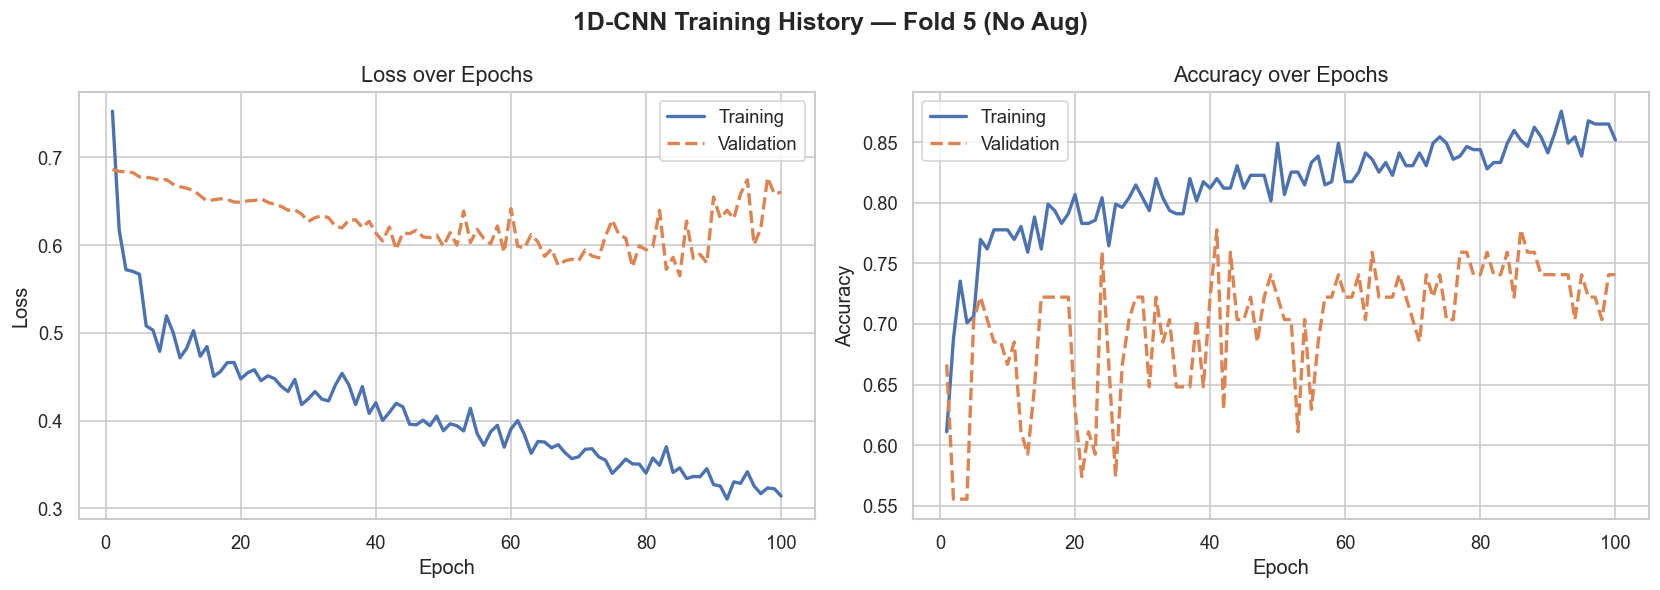

Fold 5: Accuracy=0.7290  Precision=0.7049  Recall=0.7963  F1=0.7478
  *** New best model (Fold 5, F1 = 0.7478) ***

Cross-validation complete.
Best fold F1-score : 0.7478


In [ ]:
os.makedirs('../../saved_models/revised_no_augmentation', exist_ok=True)

cnn_fold_metrics = []
cnn_best_model   = None
cnn_best_scaler  = None
cnn_best_f1      = 0.0
cnn_all_y_true   = []
cnn_all_y_pred   = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):

    print(f"\n{'='*56}")
    print(f'  Fold {fold + 1} / {skf.n_splits}')
    print(f"{'='*56}")

    # 1. Split into training fold and test fold
    X_train_fold = X[train_idx]
    X_test_fold  = X[test_idx]
    y_train_fold = y[train_idx]
    y_test_fold  = y[test_idx]

    print(f'  Train fold : {X_train_fold.shape[0]} samples')
    print(f'  Test fold  : {X_test_fold.shape[0]} samples')

    # 2. Carve out a real validation set for EarlyStopping
    val_splitter = StratifiedShuffleSplit(
        n_splits=1, test_size=0.125, random_state=RANDOM_STATE
    )
    train_sub_idx, val_idx = next(val_splitter.split(X_train_fold, y_train_fold))

    X_train_sub = X_train_fold[train_sub_idx]
    y_train_sub = y_train_fold[train_sub_idx]
    X_val_real  = X_train_fold[val_idx]
    y_val_real  = y_train_fold[val_idx]

    print(f'  Training (no aug) : {X_train_sub.shape[0]} samples')
    print(f'  Real validation   : {X_val_real.shape[0]} samples (used by EarlyStopping)')

    # 3. Scale -- fit on raw training sub-split only
    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_sub)
    X_val_scaled   = scaler.transform(X_val_real)
    X_test_scaled  = scaler.transform(X_test_fold)

    # 4. Reshape for Conv1D
    X_train_cnn = reshape_for_cnn(X_train_scaled)
    X_val_cnn   = reshape_for_cnn(X_val_scaled)
    X_test_cnn  = reshape_for_cnn(X_test_scaled)

    # 5. Build a fresh CNN for this fold
    model = build_1d_cnn(input_length=700)

    ckpt_path = f'../../saved_models/revised_no_augmentation/cnn_fold_{fold + 1}.keras'
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True,
            verbose=0,
        ),
        ModelCheckpoint(
            filepath=ckpt_path,
            monitor='val_loss',
            save_best_only=True,
            verbose=0,
        ),
    ]

    # 6. Train with real validation_data (batch_size=32 for smaller dataset)
    history = model.fit(
        X_train_cnn, y_train_sub,
        epochs=100,
        batch_size=32,
        validation_data=(X_val_cnn, y_val_real),
        callbacks=callbacks,
        verbose=1,
    )
    print(f'Fold {fold + 1} stopped at epoch {len(history.history["loss"])}')

    plot_training_history(history, title=f'1D-CNN Training History — Fold {fold + 1} (No Aug)')
    plt.show()

    # 7. Predict on the untouched test fold
    y_prob = model.predict(X_test_cnn, verbose=0)[:, 0]
    y_pred = (y_prob >= 0.5).astype(int)

    # 8. Compute metrics
    acc  = accuracy_score(y_test_fold, y_pred)
    prec = precision_score(y_test_fold, y_pred, zero_division=0)
    rec  = recall_score(y_test_fold, y_pred, zero_division=0)
    f1   = f1_score(y_test_fold, y_pred, zero_division=0)

    print(f'Fold {fold + 1}: Accuracy={acc:.4f}  Precision={prec:.4f}  '
          f'Recall={rec:.4f}  F1={f1:.4f}')

    cnn_fold_metrics.append({'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1})
    cnn_all_y_true.append(y_test_fold)
    cnn_all_y_pred.append(y_pred)

    if f1 > cnn_best_f1:
        cnn_best_f1     = f1
        cnn_best_model  = model
        cnn_best_scaler = scaler
        print(f'  *** New best model (Fold {fold + 1}, F1 = {cnn_best_f1:.4f}) ***')

print(f'\nCross-validation complete.')
print(f'Best fold F1-score : {cnn_best_f1:.4f}')

## Section 5 — CNN Results Summary

  1D-CNN 5-Fold CV Results (No Augmentation)
  Accuracy  : 0.7050 +/- 0.0614
  Precision : 0.7045 +/- 0.0784
  Recall    : 0.7407 +/- 0.1355
  F1-Score  : 0.7134 +/- 0.0615

Per-fold breakdown:
   Accuracy  Precision    Recall  F1-Score
0  0.648148   0.660000  0.611111  0.634615
1  0.796296   0.785714  0.814815  0.800000
2  0.648148   0.595238  0.925926  0.724638
3  0.712963   0.767442  0.611111  0.680412
4  0.719626   0.714286  0.740741  0.727273


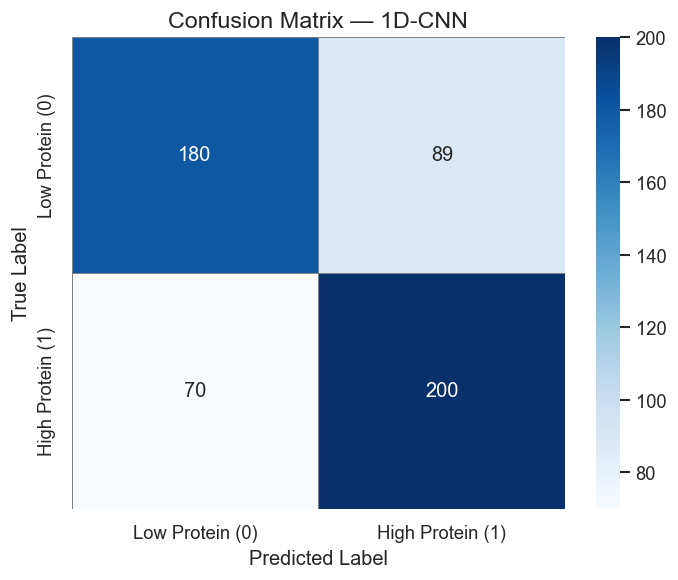

In [5]:
metrics_df = pd.DataFrame(cnn_fold_metrics)

mean_acc  = metrics_df['accuracy'].mean()
std_acc   = metrics_df['accuracy'].std()
mean_prec = metrics_df['precision'].mean()
std_prec  = metrics_df['precision'].std()
mean_rec  = metrics_df['recall'].mean()
std_rec   = metrics_df['recall'].std()
mean_f1   = metrics_df['f1'].mean()
std_f1    = metrics_df['f1'].std()

print('====================================================')
print('  1D-CNN 5-Fold CV Results (No Augmentation)')
print('====================================================')
print(f'  Accuracy  : {mean_acc:.4f} +/- {std_acc:.4f}')
print(f'  Precision : {mean_prec:.4f} +/- {std_prec:.4f}')
print(f'  Recall    : {mean_rec:.4f} +/- {std_rec:.4f}')
print(f'  F1-Score  : {mean_f1:.4f} +/- {std_f1:.4f}')
print('====================================================')

print('\nPer-fold breakdown:')
print(metrics_df.rename(columns={
    'accuracy': 'Accuracy', 'precision': 'Precision',
    'recall': 'Recall', 'f1': 'F1-Score',
}).to_string(index=True))

y_true_all = np.concatenate(cnn_all_y_true)
y_pred_all = np.concatenate(cnn_all_y_pred)

plot_cnn_confusion_matrix(y_true_all, y_pred_all)
plt.show()

## Section 6 — Save Best CNN Model

In [6]:
import joblib

keras_path = '../../saved_models/revised_no_augmentation/1d_cnn_best.keras'
cnn_best_model.save(keras_path)
print(f'CNN model weights saved to: {keras_path}')

cnn_bundle = {
    'model_type': '1D-CNN',
    'scaler': cnn_best_scaler,
    'keras_path': keras_path,
}
joblib.dump(cnn_bundle, '../../saved_models/revised_no_augmentation/1d_cnn_best.pkl')
print('CNN bundle saved to: saved_models/revised_no_augmentation/1d_cnn_best.pkl')
print(f'Best fold F1-score: {cnn_best_f1:.4f}')

CNN model weights saved to: ../../saved_models/revised_no_augmentation/1d_cnn_best.keras
CNN bundle saved to: saved_models/revised_no_augmentation/1d_cnn_best.pkl
Best fold F1-score: 0.8000


## Section 7 — Save Per-Fold Metrics to Disk

In [7]:
import json

os.makedirs('../../data/results/no_aug', exist_ok=True)

def get_f1(m):
    return m.get('f1_score', m.get('f1', 0.0))

cnn_results = {
    'model': '1D-CNN',
    'fold_metrics': [
        {
            'fold':      i + 1,
            'accuracy':  m['accuracy'],
            'precision': m['precision'],
            'recall':    m['recall'],
            'f1_score':  get_f1(m),
        }
        for i, m in enumerate(cnn_fold_metrics)
    ],
    'mean_accuracy':  float(np.mean([m['accuracy']  for m in cnn_fold_metrics])),
    'std_accuracy':   float(np.std( [m['accuracy']  for m in cnn_fold_metrics])),
    'mean_precision': float(np.mean([m['precision'] for m in cnn_fold_metrics])),
    'std_precision':  float(np.std( [m['precision'] for m in cnn_fold_metrics])),
    'mean_recall':    float(np.mean([m['recall']    for m in cnn_fold_metrics])),
    'std_recall':     float(np.std( [m['recall']    for m in cnn_fold_metrics])),
    'mean_f1':        float(np.mean([get_f1(m)      for m in cnn_fold_metrics])),
    'std_f1':         float(np.std( [get_f1(m)      for m in cnn_fold_metrics])),
    'all_y_true':     [int(v) for v in np.concatenate(cnn_all_y_true)],
    'all_y_pred':     [int(v) for v in np.concatenate(cnn_all_y_pred)],
}

with open('../../data/results/no_aug/cnn_results.json', 'w') as f:
    json.dump(cnn_results, f, indent=2)
print('1D-CNN results saved to: data/results/no_aug/cnn_results.json')

1D-CNN results saved to: data/results/no_aug/cnn_results.json


## Section 8 — Summary

| Item | Detail |
|---|---|
| **Augmentation** | None — CNN trained on raw ~56 samples per fold |
| **Evaluation method** | 5-Fold Stratified Cross Validation |
| **Preprocessing** | `StandardScaler` fitted inside each fold on raw training sub-split only |
| **Training** | Up to 100 epochs, batch size 32, EarlyStopping patience=20 |
| **Next notebook** | `notebooks/revised_no_augmentation/07_evaluation_metrics_no_aug.ipynb` |